In [1]:
import pandas as pd

In [1]:
import pickle

with open("data/Direct_Binders_Dictionary_Enriched.pkl", "rb") as f:
    db = pickle.load(f)

print("Total entries:", len(db))

# Check few entries
for i, (k, v) in enumerate(db.items()):
    print(v)
    if i == 5:
        break

Total entries: 5633814
{'Target ID': 'ChEMBL_T_01', 'Target': 'Eukaryotic peptide chain release factor GTP-binding subunit (Gene: CHEMBL3308902, UniProt: P05453)', 'Ligand Name': 'TERAIODOPHENOLPHATHALIN', 'SMILE': 'O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I)=C2)C=C1I', 'Fragments': "['*O', '*C(=O)c1ccccc1C(=C1C=C(I)C(=O)C(I)=C1)C1C=C(I)C(=O)C(I)=C1', '*C1C=C(I)C(=O)C(I)=C1', '*C(c1ccccc1C(=O)O)C1C=C(I)C(=O)C(I)=C1']", 'Organism': 'Saccharomyces cerevisiae', 'Assay': 'CHEMBL1220168 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (DE3) assessed as inhibition of amyloid polymerization by thioflavin T fluorescence assay relative to untreated control', 'AssayID': 'CHEMBL1220168', 'Target_Atom_Count': 0}
{'Target ID': 'ChEMBL_T_01', 'Target': 'Eukaryotic peptide chain release factor GTP-binding subunit (Gene: CHEMBL3308902, UniProt: P05453)', 'Ligand Name': 'SULCONAZOLE', 'SMILE': 'Clc1ccc(CSC(Cn2ccnc2)c2ccc(Cl)cc2Cl)cc1', 'Fragments': "

In [2]:
sum(1 for v in db.values() if "Original_SMILES" in v)
sum(1 for v in db.values() if v.get("Target_Atom_Count", 0) > 0)

0

In [2]:
import os
import sys
import time
import pickle
import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem.rdmolops import DeleteSubstructs
from rdkit import RDLogger

RDLogger.DisableLog('rdApp.*')
sys.setrecursionlimit(50000)

FINAL_MAGNET_CSV = "/storage/savi/saveenas/Projects/Magnet/Dataset/FINAL_MAGNET_DATABASE/Final_MagnetDB.csv"
DIRECT_BINDERS_PKL = "/storage/savi/saveenas/Projects/Magnet/Magnet_Package/Direct_Binders_Dictionary.pkl"

# We will output TWO files now, exactly like your diagram
OUTPUT_HASH_MAP = "data_copy/Clean_Metadata_Hash.pkl"
OUTPUT_LEAN_TRIE = "data_copy/Lean_MagnetDB_Trie.pkl"

# =================================================================
# 1. TRIE CLASSES (Extremely Lightweight Now)
# =================================================================
""" class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.tag_ids = set() # ONLY stores the Database IDs (Hash Keys)

class LeanTrie:
    def __init__(self):
        self.root = TrieNode()

    def insert(self, word, db_id):
        node = self.root
        for char in word:
            if char not in node.children:
                node.children[char] = TrieNode()
            node = node.children[char]
        node.is_end_of_word = True
        node.tag_ids.add(db_id)

    def __getstate__(self):
        return self.root

    def __setstate__(self, state):
        self.root = state """
from trie_structures import LeanTrie, TrieNode
# =================================================================
# 2. RDKit ATOM COUNTER
# =================================================================
def get_heavy_atom_count(smile):
    try:
        mol = Chem.MolFromSmiles(smile)
        if not mol: return 0
        dummy = Chem.MolFromSmarts('[#0]') 
        clean_mol = DeleteSubstructs(mol, dummy)
        return clean_mol.GetNumHeavyAtoms()
    except:
        return 0

if __name__ == "__main__":
    start = time.time()
    
    print("Loading Raw Databases...")
    magnet_df = pd.read_csv(FINAL_MAGNET_CSV)
    with open(DIRECT_BINDERS_PKL, 'rb') as f:
        raw_binders_dict = pickle.load(f)

    # =================================================================
    # PHASE A: Build the Hash Map (Pre-compute RDKit math ONCE)
    # =================================================================
    print("\n[Phase A] Pre-computing Hash Map & Dropping <8 Atom Junk...")
    clean_hash_map = {}
    dropped_count = 0
    
    for db_id, target_info in tqdm(raw_binders_dict.items(), desc="Hashing Targets"):
        raw_smiles = str(target_info.get('SMILE', ''))
        atom_count = get_heavy_atom_count(raw_smiles)
        
        if atom_count < 8:
            dropped_count += 1
            continue
            
        clean_hash_map[db_id] = {
            "Target_ID": target_info.get('Target ID', ''),
            "Target_Name": target_info.get('Target', 'Unknown Protein'),
            "Ligand_Name": target_info.get('Ligand Name', 'Unknown Ligand'),
            "Organism": target_info.get('Organism', 'Unknown Organism'),
            "Assay": target_info.get('Assay', 'No Assay Data'),
            "Original_SMILES": raw_smiles,
            "Target_Atom_Count": atom_count # PRE-CALCULATED! No RDKit needed in inference!
        }

    print(f"🗑️ Dropped {dropped_count} junk targets.")
    print(f"💾 Saving Clean Hash Map ({len(clean_hash_map)} entries)...")
    with open(OUTPUT_HASH_MAP, 'wb') as f:
        pickle.dump(clean_hash_map, f, protocol=pickle.HIGHEST_PROTOCOL)

    # =================================================================
    # PHASE B: Build the Lean Trie
    # =================================================================
    print("\n[Phase B] Building Lean Trie (Lightning Fast)...")
    trie = LeanTrie()
    
    fragments = magnet_df['Fragment'].astype(str).tolist()
    sources = magnet_df['Source'].astype(str).tolist()

    for frag, source_str in tqdm(zip(fragments, sources), total=len(fragments), desc="Building Trie"):
        if frag == 'nan' or not frag: continue
            
        source_ids = source_str.split(', ') if source_str != 'nan' else []
        
        for source_id in source_ids:
            # Only add to Trie if the target survived the Hash Map cleaning
            if source_id in clean_hash_map:
                trie.insert((frag + "$")[::-1], source_id)
                
    print("💾 Saving Lean Trie to disk...")
    with open(OUTPUT_LEAN_TRIE, 'wb') as f:
        pickle.dump(trie, f, protocol=pickle.HIGHEST_PROTOCOL)
        
    print(f"\n✅ FULL ARCHITECTURE BUILT IN {time.time() - start:.2f} SECONDS!")

Loading Raw Databases...

[Phase A] Pre-computing Hash Map & Dropping <8 Atom Junk...


Hashing Targets: 100%|██████████| 5633814/5633814 [18:56<00:00, 4956.66it/s] 


🗑️ Dropped 2187 junk targets.
💾 Saving Clean Hash Map (5631627 entries)...

[Phase B] Building Lean Trie (Lightning Fast)...


Building Trie: 100%|██████████| 2471351/2471351 [08:37<00:00, 4778.53it/s] 


💾 Saving Lean Trie to disk...

✅ FULL ARCHITECTURE BUILT IN 1871.72 SECONDS!


In [3]:
import time
import pickle
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Recap
from rdkit.Chem.rdmolops import DeleteSubstructs

# =================================================================
# 1. LOCAL CLASSES (For Jupyter Unpickling)
# =================================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.tag_ids = set() # Only holds the IDs now!

class LeanTrie:
    def __init__(self):
        self.root = TrieNode()
    def __getstate__(self): return self.root
    def __setstate__(self, state): self.root = state

# =================================================================
# 2. RDKIT ATOM COUNTER (Only needed for the Query User SMILES now!)
# =================================================================
def get_heavy_atom_count(smile):
    try:
        mol = Chem.MolFromSmiles(smile)
        if not mol: return 0
        dummy = Chem.MolFromSmarts('[#0]') 
        clean_mol = DeleteSubstructs(mol, dummy)
        return clean_mol.GetNumHeavyAtoms()
    except:
        return 0

# =================================================================
# 3. FAST DUAL-FILE INFERENCE
# =================================================================
def predict_targets(user_smiles, query_name="User_Molecule", min_query_cov=25.0, min_target_cov=75.0):
    print(f"\n{'='*50}\n🔍 SYNGLUE INFERENCE (FAST MODE): {query_name}\n{'='*50}")
    
    t0_load = time.time()
    
    # Load BOTH the Lean Trie and the Hash Map
    with open("Lean_MagnetDB_Trie.pkl", "rb") as f:
        trie = pickle.load(f)
    with open("Clean_Metadata_Hash.pkl", "rb") as f:
        metadata_hash = pickle.load(f)
        
    print(f"✅ Databases loaded in: {time.time() - t0_load:.4f} seconds.")
    
    t0_inference = time.time()
    mol = Chem.MolFromSmiles(user_smiles)
    hierarchy = Recap.RecapDecompose(mol)
    terminal_fragments = [smi for smi, node in hierarchy.children.items() if smi.count('*') == 1]
    
    q_smile_atoms = get_heavy_atom_count(user_smiles)
    results = []

    for frag in terminal_fragments:
        node = trie.root
        match_found = True
        for char in (frag + "$")[::-1]:
            if char not in node.children:
                match_found = False
                break
            node = node.children[char]
            
        if match_found and node.is_end_of_word:
            q_frag_atoms = get_heavy_atom_count(frag)
            
            # Lookup the IDs in the Hash Map!
            for db_id in node.tag_ids:
                if db_id in metadata_hash:
                    meta = metadata_hash[db_id]
                    
                    # Grab the PRE-CALCULATED atom count (Lightning fast!)
                    t_smile_atoms = meta["Target_Atom_Count"]
                    
                    q_cov = (q_frag_atoms / q_smile_atoms) * 100 if q_smile_atoms else 0
                    t_cov = (q_frag_atoms / t_smile_atoms) * 100 if t_smile_atoms else 0
                    
                    # Sanity Filter: Must be <= 100.0%
                    if q_cov >= min_query_cov and (min_target_cov <= t_cov <= 100.0):
                        results.append({
                            "Database_ID": db_id,
                            "Target_ID": meta["Target_ID"],
                            "Target_Name": meta["Target_Name"],
                            "Ligand_Name": meta["Ligand_Name"],
                            "Organism": meta["Organism"],
                            "Assay": meta["Assay"],
                            "Magnet_ID": "N/A", # Handled by Trie previously
                            "query_frag_smile": frag,
                            "original_target_smile": meta["Original_SMILES"],
                            "query_smile_atom_count": q_smile_atoms,
                            "Query_Percentage": round(q_cov, 2),
                            "Target_Percentage": round(t_cov, 2)
                        })

    df_results = pd.DataFrame(results)
    if not df_results.empty:
        df_results = df_results.sort_values(by="Target_Percentage", ascending=False).reset_index(drop=True)
        out_csv = f"{query_name}_Mapped_Targets.csv"
        df_results.to_csv(out_csv, index=False)
        print(f"⚡ Inference completed in: {time.time() - t0_inference:.5f} seconds!")
        print(f"💾 Full results saved to {out_csv} ({len(df_results)} clean hits)")
    else:
        print("⚠️ No valid targets found passing the thresholds.")
        
    return df_results

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    predict_targets(user_smiles=IMATINIB_SMILES, query_name="Imatinib", min_query_cov=25.0, min_target_cov=75.0)


🔍 SYNGLUE INFERENCE (FAST MODE): Imatinib
✅ Databases loaded in: 413.4429 seconds.
⚡ Inference completed in: 1.07040 seconds!
💾 Full results saved to Imatinib_Mapped_Targets.csv (9451 clean hits)


Loading data from Imatinib_Mapped_Targets.csv...
Validating True Structural Overlap (MCS) to ensure CSV math is flawless...


Updating CSV Math: 100%|██████████| 9451/9451 [01:17<00:00, 121.40it/s]


--- Running Type Analysis ---
💾 Saved strictly validated results to Imatinib_Mapped_Targets_Validated.csv

Highlighting Top 3 Mapped Targets...

🎯 Target Protein:      SMS_T_70
📝 Full Protein Name:   36: , 25.0, Tyrosine-protein kinase ABL Inhibition of human recombinant Abl: ABL1: , P00519, PROTEIN-PROTEIN INTERACTION, CHEMBL4523751
🦠 Organism:            Homo sapiens
🧬 Polypharmacy Class:  Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
   • Database ID:       SMS_247525
   • Ligand Name:       CHEMBL941: IMATINIB
   • Query Coverage:    100.0%
   • Target Coverage:   100.0%
Query Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target Functional Groups: carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)



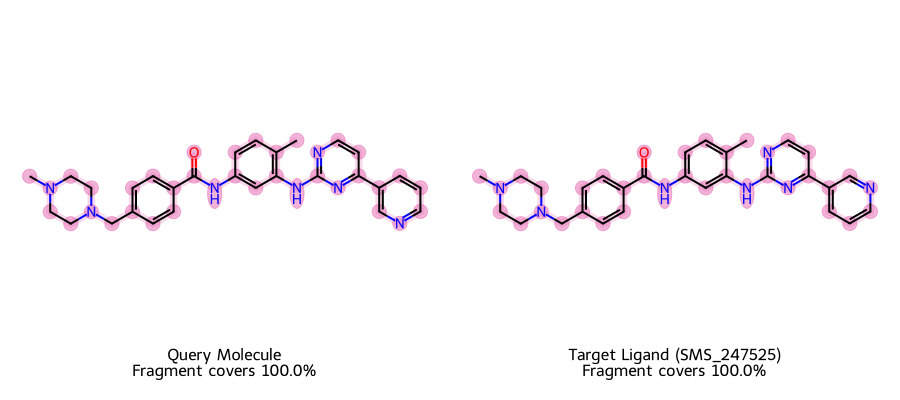


🎯 Target Protein:      SMS_T_61
📝 Full Protein Name:   36: , 25.0, Tyrosine-protein kinase ABL Inhibition of human recombinant Abl by filter-binding assay: ABL1: , P00519, CHIMERIC PROTEIN, CHEMBL2096618
🦠 Organism:            Homo sapiens
🧬 Polypharmacy Class:  Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
   • Database ID:       SMS_248000
   • Ligand Name:       CHEMBL941: IMATINIB
   • Query Coverage:    100.0%
   • Target Coverage:   100.0%
Query Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target Functional Groups: carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)



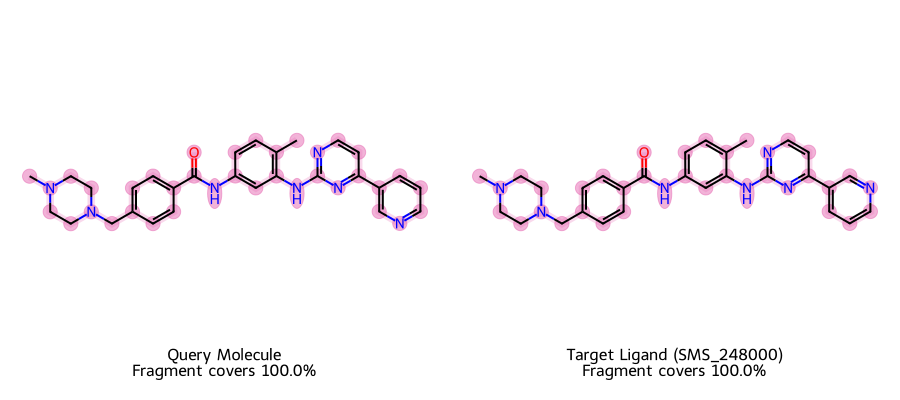


🎯 Target Protein:      SMS_T_69
📝 Full Protein Name:   2689: , 3932.0, Tyrosine-protein kinase LCK Average Binding Constant for LCK; NA=Not Active at 10 uM: LCK: , P06239, PROTEIN-PROTEIN INTERACTION, CHEMBL4523727
🦠 Organism:            Homo sapiens
🧬 Polypharmacy Class:  Type 2 (Monovalent Multitarget)
------------------------------------------------------------------------------------------
   • Database ID:       SMS_246772
   • Ligand Name:       CHEMBL941: IMATINIB
   • Query Coverage:    100.0%
   • Target Coverage:   100.0%
Query Functional Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target Functional Groups: carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)



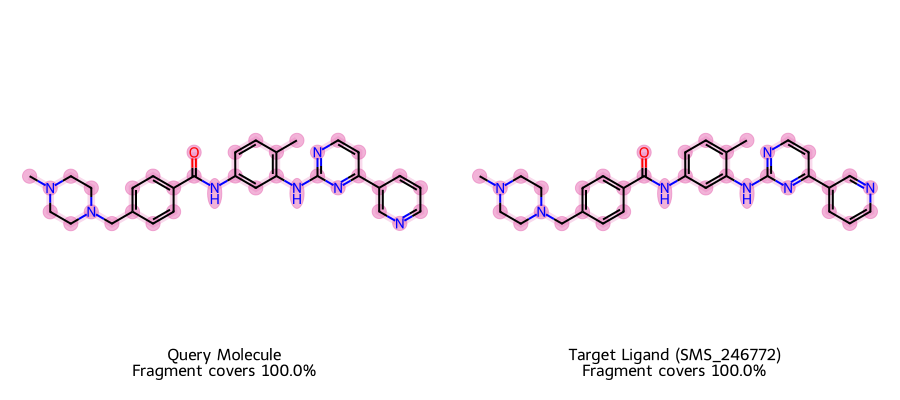

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Recap, rdFMCS
from rdkit.Chem.Draw import rdDepictor
from rdkit import RDLogger
from tqdm import tqdm
from IPython.display import display

# =====================================================================
# 1. VISUALIZATION STYLING & CLEANUP
# =====================================================================
RDLogger.DisableLog('rdApp.*') # Mutes strict RDKit SMARTS warnings

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
    "axes.linewidth": 1.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out"
})

# =====================================================================
# 2. MASTER CHEMICAL GROUPS DICTIONARY
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'}, 'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'}, 'ketone': {'smarts': 'C(=O)C'},
    'thiocarbonyl compound': {'smarts': 'C=S'}, 'imine': {'smarts': 'C=N'},
    'hydrazone': {'smarts': 'C=N-N'}, 'oxime': {'smarts': 'C=N-[OH]'},
    'ether': {'smarts': 'C-O-C'}, 'carboxylic acid': {'smarts': 'C(=O)[OH]'},
    'ester': {'smarts': 'C(=O)O-C'}, 'amide': {'smarts': 'C(=O)N'},
    'primary amine': {'smarts': '[NX3H2]'}, 'secondary amine': {'smarts': '[NX3H1]'},
    'tertiary amine': {'smarts': '[NX3H0]'}, 'alcohol': {'smarts': '[OX2H]'},
    'phenol': {'smarts': 'c1ccccc1[OH]'}, 'thiol': {'smarts': '[SX2H]'},
    'thioether': {'smarts': 'C-S-C'}, 'disulfide': {'smarts': 'S-S'},
    'sulfonamide': {'smarts': 'S(=O)(=O)N'}, 'sulfone': {'smarts': 'S(=O)(=O)C'},
    'sulfonic acid': {'smarts': 'S(=O)(=O)[OH]'}, 'phosphate': {'smarts': 'O=P(O)(O)O'},
    'halogen': {'smarts': '[F,Cl,Br,I]'}, 'trifluoromethyl': {'smarts': 'C(F)(F)F'},
    'cyanide / nitrile': {'smarts': 'C#N'}, 'nitro': {'smarts': 'N(=O)=O'},
    'azide': {'smarts': 'N=N=N'}, 'alkyne': {'smarts': 'C#C'},
    'alkene': {'smarts': 'C=C'}, 'furan': {'smarts': 'c1cocc1'},
    'thiophene': {'smarts': 'c1cscc1'}, 'pyrrole': {'smarts': 'c1cc[nH]c1'},
    'pyridine': {'smarts': 'c1ccncc1'}, 'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'}, 'pyrazole': {'smarts': 'c1c[nH]nc1'},
}

def identify_functional_groups(mol):
    detected = []
    for name, properties in MASTER_CHEMICAL_GROUPS.items():
        pattern = Chem.MolFromSmarts(properties['smarts'])
        if pattern is None: continue 
        matches = mol.GetSubstructMatches(pattern)
        if matches: detected.append(f"{name} ({len(matches)})")
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 3. POLYPHARMACOLOGY TYPE ANALYSIS
# =====================================================================
TYPE_NAMES = {
    "Type 1": "Type 1 (Monovalent Monotarget)",
    "Type 2": "Type 2 (Monovalent Multitarget)",
    "Type 3": "Type 3 (Multivalent Monotarget)",
    "Type 4": "Type 4 (Multivalent Multitarget)",
    "Type 5": "Type 5 (Unclassified)"
}

def perform_type_analysis(df, parent_smiles):
    print("--- Running Type Analysis ---")
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    def get_mcs_smile(q_mol, t_mol):
        if q_mol is None or t_mol is None: return None
        mcs = rdFMCS.FindMCS([q_mol, t_mol], timeout=3)
        if mcs is None or not mcs.smartsString: return None
        return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True)

    query_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True)
    query_frag_mol = Chem.MolFromSmiles(query_frag)
    s1map_list = [query_frag]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        mcs_smile = get_mcs_smile(query_frag_mol, Chem.MolFromSmiles(target_frag))
        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True): s1map_list.append(target_frag)
        else: s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1_frag in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1_frag), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2_frag in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2_frag), Chem.MolFromSmiles(query)) == query: s2_match = True

    if len(unique_queries) < 1: result = "Type 5"
    elif len(unique_queries) == 1: result = "Type 1" if unique_target_count == 1 else "Type 2"
    else: result = ("Type 1" if unique_target_count == 1 else "Type 2") if not s1_match and not s2_match else ("Type 3" if unique_target_count == 1 else "Type 4")

    df['Polypharmacology_Type'] = result
    return df

# =====================================================================
# 4. MAIN PIPELINE (True MCS Math -> Filter -> Visualize)
# =====================================================================
def analyze_and_visualize(csv_path, parent_smiles):
    print(f"Loading data from {csv_path}...")
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: {csv_path} not found.")
        return

    # INITIAL FILTER: Drop junk hits immediately
    df = df[df['query_smile_atom_count'] >= 10].copy()

    # -----------------------------------------------------------------
    # THE BIG FIX: Recalculate CSV using True MCS Structural Overlap
    # -----------------------------------------------------------------
    print("Validating True Structural Overlap (MCS) to ensure CSV math is flawless...")
    tqdm.pandas(desc="Updating CSV Math")
    
    parent_mol = Chem.MolFromSmiles(parent_smiles)
    parent_atoms = parent_mol.GetNumHeavyAtoms()

    def get_true_coverage(row):
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])
        if not t_mol: return pd.Series([0.0, 0.0])

        # Find the exact overlap between the two parent molecules
        mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=2, ringMatchesRingOnly=True, completeRingsOnly=True)
        if not mcs or not mcs.smartsString:
            mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=2) # Fallback

        shared_atoms = Chem.MolFromSmarts(mcs.smartsString).GetNumHeavyAtoms() if (mcs and mcs.smartsString) else 0
        t_atoms = t_mol.GetNumHeavyAtoms()
        
        # Calculate the perfect percentages
        true_q_cov = (shared_atoms / parent_atoms) * 100 if parent_atoms else 0
        true_t_cov = (shared_atoms / t_atoms) * 100 if t_atoms else 0
        return pd.Series([true_q_cov, true_t_cov])

    # Overwrite the CSV columns with the perfect math!
    df[['Query_Percentage', 'Target_Percentage']] = df.progress_apply(get_true_coverage, axis=1)

    # -----------------------------------------------------------------
    # APPLY FILTERS & SAVE NEW CSV
    # -----------------------------------------------------------------
    df = df[df["Query_Percentage"] >= 25]
    df = df[df["Target_Percentage"] >= 75]
    df = df[df["Target_Percentage"] <= 100.0]

    if len(df) == 0:
        print("⚠️ No matches survived the true MCS validation thresholds.")
        return

    df = perform_type_analysis(df, parent_smiles)
    
    # Save the perfect CSV!
    val_csv_path = csv_path.replace(".csv", "_Validated.csv")
    df.to_csv(val_csv_path, index=False)
    print(f"💾 Saved strictly validated results to {val_csv_path}")

    # -----------------------------------------------------------------
    # VISUALIZE TOP 3
    # -----------------------------------------------------------------
    # EXACT SORTING: Absolute best Target % then Query %
    vis_df = df.sort_values(
        by=['Target_Percentage', 'Query_Percentage'], 
        ascending=[False, False]
    ).drop_duplicates(subset=['Target_ID', 'original_target_smile']).head(3)
    
    rdDepictor.SetPreferCoordGen(True)
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5)) 
    
    print("\nHighlighting Top 3 Mapped Targets...")
    for i, row in vis_df.iterrows():
        descriptive_type = TYPE_NAMES.get(row['Polypharmacology_Type'], row['Polypharmacology_Type'])
        
        print("\n" + "=" * 90)
        print(f"🎯 Target Protein:      {row.get('Target_ID', 'Unknown')}")
        print(f"📝 Full Protein Name:   {row.get('Target_Name', 'Unknown')}")
        print(f"🦠 Organism:            {row.get('Organism', 'Unknown')}")
        print(f"🧬 Polypharmacy Class:  {descriptive_type}")
        print("-" * 90)
        print(f"   • Database ID:       {row.get('Database_ID', 'N/A')}")
        print(f"   • Ligand Name:       {row.get('Ligand_Name', 'N/A')}")
        print(f"   • Query Coverage:    {row['Query_Percentage']:.1f}%")
        print(f"   • Target Coverage:   {row['Target_Percentage']:.1f}%")
        print("=" * 90)
        
        t_mol = Chem.MolFromSmiles(row['original_target_smile'])
        if not parent_mol or not t_mol: continue

        # Redo the MCS just to get the exact atoms to draw the pink highlights
        mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=5, ringMatchesRingOnly=True, completeRingsOnly=True)
        if not mcs or not mcs.smartsString: mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=5)
            
        if mcs and mcs.smartsString:
            mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
            match_parent = parent_mol.GetSubstructMatch(mcs_mol)
            match_target = t_mol.GetSubstructMatch(mcs_mol)
        else:
            match_parent = (); match_target = ()

        print(f"Query Functional Groups:  {identify_functional_groups(parent_mol)}")
        print(f"Target Functional Groups: {identify_functional_groups(t_mol)}\n")

        # Visuals and CSV are now completely synced
        img = Draw.MolsToGridImage(
            [parent_mol, t_mol],
            highlightAtomLists=[list(match_parent), list(match_target)],
            legends=[f"Query Molecule\nFragment covers {row['Query_Percentage']:.1f}%", 
                     f"Target Ligand ({row.get('Database_ID', 'Unknown')})\nFragment covers {row['Target_Percentage']:.1f}%"],
            molsPerRow=2,
            subImgSize=(450, 400),
            useSVG=True,
            drawOptions=dopts
        )
        display(img)

if __name__ == "__main__":
    IMATINIB_SMILES = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"
    analyze_and_visualize("Imatinib_Mapped_Targets.csv", IMATINIB_SMILES)

In [11]:
AA = pd.read_csv("/storage/savi/saveenas/Projects/Magnet/Imatinib_Mapped_Targets.csv")
AA

,Database_ID,Target_ID,Target_Name,Ligand_Name,Organism,Assay,Magnet_ID,query_frag_smile,original_target_smile,query_smile_atom_count,Query_Percentage,Target_Percentage
0,ST_Y_12323,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm00005291 : imatinib,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,NaN,*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C,COC1=C(C=C2C(=C1)C(=C(C=N2)C#N)NC3=CC=C(C=C3)C...,37,64.86,100.00
1,ST_Y_4964,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm44580689 : AGN-PC-077MJ7,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,NaN,*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C,C1=CC(=C(C=C1NC(=O)C2=NSC=C2NCC3=CC=NC=C3)Cl)Cl,37,64.86,100.00
2,ST_Y_10619,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm10074640 : masitinib,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,NaN,*C(=O)c1ccc(CN2CCN(C)CC2)cc1,C1=CNC(=C1)C=C2C3=C(C=C(C=C3)F)NC2=O,37,43.24,94.12
3,ST_Y_4967,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm44580449 : AGN-PC-077MD2,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,NaN,*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C,C1=CC=C2C(=C1)C=CC(=N2)NC(=O)C3=NSC=C3NCC4=CC=...,37,64.86,92.31
4,ST_Y_4963,Yeast_STITCH_T_11,4932.YAL017W : PSK1,CIDm44580778 : AGN-PC-077MLK,saccharomyces cerevisiae,Serine/threonine-protein kinase PSK1; PAS doma...,NaN,*c1cc(NC(=O)c2ccc(CN3CCN(C)CC3)cc2)ccc1C,CC1=C(C=C(C=C1)NC(=O)C2=NSC=C2NCC3=CC=NC=C3)C(...,37,64.86,88.89
...,...,...,...,...,...,...,...,...,...,...,...,...
9446,SMS_2861826,SMS_T_705,"36: , 25.0, Tyrosine-protein kinase ABL Inhibi...",CHEMBL3098616: nan,Homo sapiens,PUBCHEM_BIOASSAY: Navigating the Kinome. (Clas...,NaN,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,37,81.08,76.92
9447,BD1146493,BD_T_611,Bcr-Abl,CHEMBL3098615 : :,Homo sapiens,NaN,NaN,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCO)CC3)cc2)cc1Nc1nc...,37,81.08,76.92
9448,SMS_2861819,SMS_T_1097,"36: , 25.0, Tyrosine-protein kinase ABL Inhibi...",CHEMBL3098616: nan,Homo sapiens,Inhibition of ErbB2,NaN,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,37,81.08,76.92
9449,SMS_2861828,SMS_T_682,"36: , 25.0, Tyrosine-protein kinase ABL Inhibi...",CHEMBL3098616: nan,Homo sapiens,PUBCHEM_BIOASSAY: Navigating the Kinome. (Clas...,NaN,*Cc1ccc(C(=O)Nc2ccc(C)c(Nc3nccc(-c4cccnc4)n3)c...,Cc1ccc(NC(=O)c2ccc(CN3CCN(CCF)CC3)cc2)cc1Nc1nc...,37,81.08,76.92


In [2]:
import pandas as pd

In [3]:
pwd

'/storage/savi/saveenas/Projects/SynGlue_Py'

In [9]:
II = pd.read_csv("/storage/savi/saveenas/Projects/SynGlue_Py/data/Targets_for_magnetdb.csv")
II

,Gene Name,UniProt ID,Target Names,New IDs
0,M14565,P05108,"Cholesterol side-chain cleavage enzyme, mitoch...",BioSNap_T_01
1,X04299,P00326,Alcohol dehydrogenase 1C,BioSNap_T_03
2,M24317,P00325,Alcohol dehydrogenase 1B,BioSNap_T_04
3,M12271,P07327,Alcohol dehydrogenase 1A,BioSNap_T_05
4,J04088,P11388,DNA topoisomerase 2-alpha,BioSNap_T_06
...,...,...,...,...
20124,Q9UE69,Q9UE69,5HT3 serotonin receptor,DB_T_889
20125,Q8I431,Q8I431,60S ribosomal protein L4,DB_T_2436
20126,C0H5C2,C0H5C2,40S ribosomal protein S19,DB_T_2440
20127,Q86DI9,Q86DI9,Sodium channel protein,DB_T_756


In [ ]:
| File                                     | Meaning                                   |
| ---------------------------------------- | ----------------------------------------- |
| `Direct_Binders_Dictionary_Enriched.pkl` | ~5.6M ligand/binder records               |
| `Direct_Binders_Clean_Summary.pkl`       | ~5.6M ligand-target rows                  |
| `Direct_Binders_Target_Map.pkl`          | ~8.6k unique target map                   |
| `Clean_Metadata_Hash.pkl`                | ~5.6M mapping hash records                |
| `Clean_Metadata_Hash_PATCHED.pkl`        | patched but still noisy ligand-level hash |


In [10]:
import pandas as pd

# Load the final clean target mapping
target_map = pd.read_csv("/storage/savi/saveenas/Projects/SynGlue_Py/data/Target_Mapping.csv")

target_map

,Target_ID,Target_Full_Name,Gene_Name,UniProt_ID,Organism
0,BD_T_01,Heat Shock Protein 90 (Hsp90),HS90A_HUMAN,P07900,Saccharomyces cerevisiae
1,BD_T_02,Homoisocitrate Dehydrogenase (HICDH),LYS12,P40495,Saccharomyces cerevisiae
2,BD_T_03,alpha-Glucosidase (alpha-Glu),MAL32_YEAST,P38158,Saccharomyces cerevisiae
3,BD_T_04,Oligosaccharyl transferase (OT),OST1_YEAST,P41543,Saccharomyces cerevisiae
4,BD_T_05,Peptidyl-prolyl cis-trans isomerase,PIN4,Q9Y237,Saccharomyces cerevisiae
...,...,...,...,...,...
8608,Yeast_STITCH_T_95,YBR053C,YBR053C,P38235,Saccharomyces cerevisiae
8609,Yeast_STITCH_T_96,YBR054W,YRO2,P38079,Saccharomyces cerevisiae
8610,Yeast_STITCH_T_97,YBR056W,YBR056W,P38081,Saccharomyces cerevisiae
8611,Yeast_STITCH_T_98,YBR058C,UBP14,P38237,Saccharomyces cerevisiae


In [12]:
target_map["Organism"].unique()

array(['Saccharomyces cerevisiae', 'Homo sapiens', 'Mus musculus'],
      dtype=object)

In [13]:
import pandas as pd

PP = pd.read_pickle(
    "/storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash_PATCHED_FROM_TARGET_MAP.pkl"
)

for k, v in list(PP.items())[:20]:
    print("Database_ID:", k)
    print("Target_ID:", v.get("Target_ID"))
    print("Target_Name:", v.get("Target_Name"))
    print("Gene_Name:", v.get("Gene_Name"))
    print("UniProt_ID:", v.get("UniProt_ID"))
    print("Resolution:", v.get("Resolution_Status"))
    print()

Database_ID: CHEMBL1212977
Target_ID: ChEMBL_T_01
Target_Name: Eukaryotic peptide chain release factor GTP-binding subunit
Gene_Name: CHEMBL3308902
UniProt_ID: P05453
Resolution: RESOLVED

Database_ID: CHEMBL1221
Target_ID: ChEMBL_T_01
Target_Name: Eukaryotic peptide chain release factor GTP-binding subunit
Gene_Name: CHEMBL3308902
UniProt_ID: P05453
Resolution: RESOLVED

Database_ID: CHEMBL104
Target_ID: ChEMBL_T_02
Target_Name: General amino-acid permease GAP1
Gene_Name: CHEMBL3308953
UniProt_ID: P19145
Resolution: RESOLVED

Database_ID: CHEMBL1484
Target_ID: ChEMBL_T_02
Target_Name: General amino-acid permease GAP1
Gene_Name: CHEMBL3308953
UniProt_ID: P19145
Resolution: RESOLVED

Database_ID: CHEMBL46666
Target_ID: ChEMBL_T_04
Target_Name: Alpha-glucosidase MAL62
Gene_Name: CHEMBL4357
UniProt_ID: P07265
Resolution: RESOLVED

Database_ID: CHEMBL106
Target_ID: ChEMBL_T_05
Target_Name: Eukaryotic peptide chain release factor GTP-binding subunit
Gene_Name: CHEMBL3308902
UniProt_ID: P054

In [8]:
HH = pd.read_pickle("/storage/savi/saveenas/Projects/SynGlue_Py/data/Direct_Binders_Dictionary_Enriched.pkl")
HH

{'CHEMBL1212977': {'Target ID': 'ChEMBL_T_01',
  'Target': 'Eukaryotic peptide chain release factor GTP-binding subunit (Gene: CHEMBL3308902, UniProt: P05453)',
  'Ligand Name': 'TERAIODOPHENOLPHATHALIN',
  'SMILE': 'O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I)=C2)C=C1I',
  'Fragments': "['*O', '*C(=O)c1ccccc1C(=C1C=C(I)C(=O)C(I)=C1)C1C=C(I)C(=O)C(I)=C1', '*C1C=C(I)C(=O)C(I)=C1', '*C(c1ccccc1C(=O)O)C1C=C(I)C(=O)C(I)=C1']",
  'Organism': 'Saccharomyces cerevisiae',
  'Assay': 'CHEMBL1220168 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (DE3) assessed as inhibition of amyloid polymerization by thioflavin T fluorescence assay relative to untreated control',
  'AssayID': 'CHEMBL1220168',
  'Target_Atom_Count': 0},
 'CHEMBL1221': {'Target ID': 'ChEMBL_T_01',
  'Target': 'Eukaryotic peptide chain release factor GTP-binding subunit (Gene: CHEMBL3308902, UniProt: P05453)',
  'Ligand Name': 'SULCONAZOLE',
  'SMILE': 'Clc1ccc(CSC(Cn2ccnc2)c2

In [14]:
UU = pd.read_pickle("/storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash_FINAL_GENE_FIXED.pkl")
UU

{'CHEMBL1212977': {'Target_ID': 'ChEMBL_T_01',
  'Target_Name': 'Eukaryotic peptide chain release factor GTP-binding subunit',
  'Ligand_Name': 'CHEMBL1212977 : TERAIODOPHENOLPHATHALIN',
  'Organism': 'Saccharomyces cerevisiae',
  'Assay': 'CHEMBL1220168 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (DE3) assessed as inhibition of amyloid polymerization by thioflavin T fluorescence assay relative to untreated control',
  'Original_SMILES': 'O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I)=C2)C=C1I',
  'Target_Atom_Count': 28,
  'Database_ID': 'CHEMBL1212977',
  'Gene_Name': 'SUP35',
  'UniProt_ID': 'P05453',
  'Resolution_Source': 'CSV_BY_TARGET_ID',
  'Resolution_Status': 'RESOLVED',
  'Needs_Manual_Curation': False,
  'Original_Gene_Name_Field': 'CHEMBL3308902',
  'Gene_Name_Source': 'UniProt_ID',
  'Protein_Name_UniProt': 'Eukaryotic peptide chain release factor GTP-binding subunit',
  'Organism_UniProt': 'Saccharomyces cerevisiae (

In [4]:
import re
import pickle
import pandas as pd
from tqdm import tqdm

DATA_DIR = "/storage/savi/saveenas/Projects/SynGlue_Py/data"

DIRECT_BINDERS_PKL = f"{DATA_DIR}/Direct_Binders_Dictionary_Enriched.pkl"
CLEAN_HASH_PKL = f"{DATA_DIR}/Clean_Metadata_Hash.pkl"
TARGETS_CSV = f"{DATA_DIR}/Targets_for_magnetdb.csv"

OUT_PATCHED_HASH = f"{DATA_DIR}/Clean_Metadata_Hash_PATCHED.pkl"
OUT_TARGET_MAP = f"{DATA_DIR}/Clean_Metadata_Target_Map_PATCHED.csv.gz"


def clean_value(x):
    if x is None:
        return ""
    x = str(x).strip()
    if x.lower() in ["", "nan", "none", "null", "unknown"]:
        return ""
    return x


def parse_target_string(target_text):
    """
    Parses target strings like:
    Protein name (Gene: ABC, UniProt: P12345)
    """
    target_text = clean_value(target_text)

    gene = ""
    uniprot = ""
    clean_name = target_text

    m = re.search(
        r"\(Gene:\s*([^,\)]+),\s*UniProt:\s*([A-Za-z0-9_\-]+)\)",
        target_text,
        flags=re.IGNORECASE,
    )

    if m:
        gene = clean_value(m.group(1))
        uniprot = clean_value(m.group(2))
        clean_name = re.sub(
            r"\s*\(Gene:\s*[^,\)]+,\s*UniProt:\s*[A-Za-z0-9_\-]+\)",
            "",
            target_text,
            flags=re.IGNORECASE,
        ).strip()

    else:
        m_gene = re.search(r"Gene:\s*([^,\)]+)", target_text, flags=re.IGNORECASE)
        m_uni = re.search(r"UniProt:\s*([A-Za-z0-9_\-]+)", target_text, flags=re.IGNORECASE)

        if m_gene:
            gene = clean_value(m_gene.group(1))
        if m_uni:
            uniprot = clean_value(m_uni.group(1))

        clean_name = re.sub(r"\s*\(Gene:.*?\)", "", target_text, flags=re.IGNORECASE).strip()

    return clean_name, gene, uniprot


def build_direct_binder_lookup(direct_binders):
    """
    Build lookup from Direct_Binders_Dictionary_Enriched.pkl:
    Target_ID -> Target_Name/Gene/UniProt/Organism
    """
    lookup = {}

    for ligand_id, rec in tqdm(direct_binders.items(), desc="Scanning direct binders"):
        if not isinstance(rec, dict):
            continue

        target_id = clean_value(rec.get("Target_ID") or rec.get("Target ID"))
        target_text = clean_value(rec.get("Target") or rec.get("Target_Name") or rec.get("Target_Full_Name"))
        organism = clean_value(rec.get("Organism"))
        ligand_name = clean_value(rec.get("Ligand Name") or rec.get("Ligand_Name"))
        smiles = clean_value(rec.get("SMILE") or rec.get("SMILES"))

        if not target_id:
            continue

        target_name, gene, uniprot = parse_target_string(target_text)

        if target_id not in lookup:
            lookup[target_id] = {
                "Target_ID": target_id,
                "Target_Name": target_name,
                "Gene_Name": gene,
                "UniProt_ID": uniprot,
                "Organism": organism,
                "Example_Ligand_ChEMBL_ID": ligand_id,
                "Example_Ligand_Name": ligand_name,
                "Example_SMILES": smiles,
                "Resolution_Source": "Direct_Binders_Target_String",
            }
        else:
            # Fill missing values if later records are better
            for key, value in {
                "Target_Name": target_name,
                "Gene_Name": gene,
                "UniProt_ID": uniprot,
                "Organism": organism,
            }.items():
                if not clean_value(lookup[target_id].get(key)) and clean_value(value):
                    lookup[target_id][key] = value

    return lookup


def build_targets_csv_lookup(targets_csv):
    targets = pd.read_csv(targets_csv)

    print("Targets CSV columns:")
    print(targets.columns.tolist())

    lookup = {}

    for _, row in targets.iterrows():
        target_id = clean_value(row.get("New IDs"))
        if not target_id:
            continue

        lookup[target_id] = {
            "Target_ID": target_id,
            "Target_Name": clean_value(row.get("Target Names")),
            "Gene_Name": clean_value(row.get("Gene Name")),
            "UniProt_ID": clean_value(row.get("UniProt ID")),
            "Resolution_Source": "Targets_for_magnetdb.csv",
        }

    return lookup


print("Loading Direct_Binders_Dictionary_Enriched.pkl...")
direct_binders = pd.read_pickle(DIRECT_BINDERS_PKL)

print("Loading Clean_Metadata_Hash.pkl...")
metadata_hash = pd.read_pickle(CLEAN_HASH_PKL)

print("Building lookup from Direct_Binders...")
direct_lookup = build_direct_binder_lookup(direct_binders)

print("Building lookup from Targets_for_magnetdb.csv...")
csv_lookup = build_targets_csv_lookup(TARGETS_CSV)

print("Patching metadata hash...")
patched = {}

for db_id, meta in tqdm(metadata_hash.items(), desc="Patching Clean_Metadata_Hash"):
    if not isinstance(meta, dict):
        continue

    meta = dict(meta)

    target_id = clean_value(
        meta.get("Target_ID")
        or meta.get("Target ID")
        or meta.get("Target")
        or db_id
    )

    meta["Database_ID"] = db_id
    meta["Target_ID"] = target_id

    # Existing values
    old_target_name = clean_value(meta.get("Target_Name") or meta.get("Target"))
    old_gene = clean_value(meta.get("Gene_Name"))
    old_uniprot = clean_value(meta.get("UniProt_ID"))

    final_target_name = old_target_name
    final_gene = old_gene
    final_uniprot = old_uniprot
    source = "Existing_Metadata"

    # Priority 1: Targets_for_magnetdb.csv
    if target_id in csv_lookup:
        hit = csv_lookup[target_id]

        final_target_name = clean_value(hit.get("Target_Name")) or final_target_name
        final_gene = clean_value(hit.get("Gene_Name")) or final_gene
        final_uniprot = clean_value(hit.get("UniProt_ID")) or final_uniprot
        source = "Targets_for_magnetdb.csv"

    # Priority 2: Direct binders target string
    if target_id in direct_lookup:
        hit = direct_lookup[target_id]

        final_target_name = final_target_name or clean_value(hit.get("Target_Name"))
        final_gene = final_gene or clean_value(hit.get("Gene_Name"))
        final_uniprot = final_uniprot or clean_value(hit.get("UniProt_ID"))

        if source == "Existing_Metadata":
            source = "Direct_Binders_Target_String"
        else:
            source = source + "+Direct_Binders_Target_String"

    # Priority 3: parse from old target text if possible
    if (not final_gene or not final_uniprot) and old_target_name:
        parsed_name, parsed_gene, parsed_uniprot = parse_target_string(old_target_name)

        final_target_name = final_target_name or parsed_name
        final_gene = final_gene or parsed_gene
        final_uniprot = final_uniprot or parsed_uniprot

        if parsed_gene or parsed_uniprot:
            source = source + "+Regex_Metadata_Text"

    meta["Target_Name"] = final_target_name if final_target_name else "Unknown"
    meta["Gene_Name"] = final_gene if final_gene else "Unknown"
    meta["UniProt_ID"] = final_uniprot if final_uniprot else "Unknown"
    meta["Resolution_Source"] = source

    patched[db_id] = meta


print("Saving patched metadata hash...")
with open(OUT_PATCHED_HASH, "wb") as f:
    pickle.dump(patched, f, protocol=pickle.HIGHEST_PROTOCOL)

target_map = pd.DataFrame([
    {
        "Database_ID": db_id,
        "Target_ID": meta.get("Target_ID", "Unknown"),
        "Target_Name": meta.get("Target_Name", "Unknown"),
        "Gene_Name": meta.get("Gene_Name", "Unknown"),
        "UniProt_ID": meta.get("UniProt_ID", "Unknown"),
        "Organism": meta.get("Organism", "Unknown"),
        "Resolution_Source": meta.get("Resolution_Source", "Unknown"),
    }
    for db_id, meta in patched.items()
])

target_map.to_csv(OUT_TARGET_MAP, index=False, compression="gzip")

print("\nDone.")
print("Patched hash:", OUT_PATCHED_HASH)
print("Target map:", OUT_TARGET_MAP)

print("\nQC:")
print("Total records:", len(target_map))
print("Gene Unknown:", (target_map["Gene_Name"] == "Unknown").sum())
print("UniProt Unknown:", (target_map["UniProt_ID"] == "Unknown").sum())
print("Target Name Unknown:", (target_map["Target_Name"] == "Unknown").sum())

print("\nResolution source:")
print(target_map["Resolution_Source"].value_counts(dropna=False).head(20))

print("\nSample:")
print(target_map.head(20).to_string(index=False))

Loading Direct_Binders_Dictionary_Enriched.pkl...
Loading Clean_Metadata_Hash.pkl...
Building lookup from Direct_Binders...


Scanning direct binders: 100%|██████████| 5633814/5633814 [01:28<00:00, 63346.98it/s] 


Building lookup from Targets_for_magnetdb.csv...
Targets CSV columns:
['Gene Name', 'UniProt ID', 'Target Names', 'New IDs']
Patching metadata hash...


Patching Clean_Metadata_Hash: 100%|██████████| 5631627/5631627 [01:24<00:00, 66389.15it/s] 


Saving patched metadata hash...

Done.
Patched hash: /storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash_PATCHED.pkl
Target map: /storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Target_Map_PATCHED.csv.gz

QC:
Total records: 5631627
Gene Unknown: 3790543
UniProt Unknown: 4398245
Target Name Unknown: 0

Resolution source:
Resolution_Source
Direct_Binders_Target_String                             3836994
Targets_for_magnetdb.csv+Direct_Binders_Target_String    1793353
Direct_Binders_Target_String+Regex_Metadata_Text            1280
Name: count, dtype: int64

Sample:
  Database_ID   Target_ID                                                                                       Target_Name     Gene_Name UniProt_ID                 Organism                                     Resolution_Source
CHEMBL1212977 ChEMBL_T_01                                       Eukaryotic peptide chain release factor GTP-binding subunit CHEMBL3308902     P05453 Saccharomyces cerevisia

In [5]:
import pandas as pd

PP = pd.read_pickle("/storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash_PATCHED.pkl")

for k, v in list(PP.items())[:10]:
    print(k)
    print("Target_ID:", v.get("Target_ID"))
    print("Target_Name:", v.get("Target_Name"))
    print("Gene_Name:", v.get("Gene_Name"))
    print("UniProt_ID:", v.get("UniProt_ID"))
    print("Source:", v.get("Resolution_Source"))
    print()

CHEMBL1212977
Target_ID: ChEMBL_T_01
Target_Name: Eukaryotic peptide chain release factor GTP-binding subunit
Gene_Name: CHEMBL3308902
UniProt_ID: P05453
Source: Targets_for_magnetdb.csv+Direct_Binders_Target_String

CHEMBL1221
Target_ID: ChEMBL_T_01
Target_Name: Eukaryotic peptide chain release factor GTP-binding subunit
Gene_Name: CHEMBL3308902
UniProt_ID: P05453
Source: Targets_for_magnetdb.csv+Direct_Binders_Target_String

CHEMBL104
Target_ID: ChEMBL_T_02
Target_Name: General amino-acid permease GAP1
Gene_Name: CHEMBL3308953
UniProt_ID: P19145
Source: Targets_for_magnetdb.csv+Direct_Binders_Target_String

CHEMBL1484
Target_ID: ChEMBL_T_02
Target_Name: General amino-acid permease GAP1
Gene_Name: CHEMBL3308953
UniProt_ID: P19145
Source: Targets_for_magnetdb.csv+Direct_Binders_Target_String

CHEMBL46666
Target_ID: ChEMBL_T_04
Target_Name: Alpha-glucosidase MAL62
Gene_Name: CHEMBL4357
UniProt_ID: P07265
Source: Targets_for_magnetdb.csv+Direct_Binders_Target_String

CHEMBL106
Target_ID:

In [6]:
import pandas as pd

DATA_DIR = "/storage/savi/saveenas/Projects/SynGlue_Py/data"

target_map_pkl = f"{DATA_DIR}/Direct_Binders_Target_Map.pkl"
target_map_csv = f"{DATA_DIR}/Direct_Binders_Target_Map.csv.gz"

# Fast loading
target_map = pd.read_pickle(target_map_pkl)

# Or CSV loading
# target_map = pd.read_csv(target_map_csv)

print("Target map shape:", target_map.shape)
print(target_map.columns.tolist())

target_map.head(20)

Target map shape: (8613, 14)
['Target_ID', 'Target_Full_Name', 'Target_Clean_Name', 'Gene_Name', 'UniProt_ID', 'Organism', 'Resolution_Source', 'Resolution_Status', 'Needs_Manual_Curation', 'Example_Ligand_ChEMBL_ID', 'Example_SMILES', 'Example_Assay_ID', 'N_Ligands', 'N_Assays']


,Target_ID,Target_Full_Name,Target_Clean_Name,Gene_Name,UniProt_ID,Organism,Resolution_Source,Resolution_Status,Needs_Manual_Curation,Example_Ligand_ChEMBL_ID,Example_SMILES,Example_Assay_ID,N_Ligands,N_Assays
0,ChEMBL_T_01,Eukaryotic peptide chain release factor GTP-bi...,Eukaryotic peptide chain release factor GTP-bi...,CHEMBL3308902,P05453,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL1212977,O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I...,,2,1
1,ChEMBL_T_02,General amino-acid permease GAP1,General amino-acid permease GAP1,CHEMBL3308953,P19145,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,,2,1
2,ChEMBL_T_04,Alpha-glucosidase MAL62,Alpha-glucosidase MAL62,CHEMBL4357,P07265,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL46666,O=C(N/N=C/c1ccccc1O)C(=O)N/N=C/c1ccccc1O,,2,1
3,ChEMBL_T_2067,"Arginase-2, mitochondrial","Arginase-2, mitochondrial",CHEMBL1795148,P78540,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL300797,COC(=O)[C@@H](N)Cc1ccc(O)cc1,,33,1
4,ChEMBL_T_2237,Menin/Histone-lysine N-methyltransferase MLL,Menin/Histone-lysine N-methyltransferase MLL,CHEMBL2093861,Q03164,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL93127,NCC(=O)N[C@@H](Cc1cnc[nH]1)C(=O)O,,5083,1
5,ChEMBL_T_2264,DNA topoisomerase II,DNA topoisomerase II,CHEMBL2094255,Q02880,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL55830,COC(=O)[C@@H](N)Cc1c[nH]c2ccccc12,,634,1
6,ChEMBL_T_2266,Adenosine A2 receptor,Adenosine A2 receptor,CHEMBL2094257,P29274,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL51969,COC(=O)[C@@H](N)Cc1ccccc1,,459,1
7,ChEMBL_T_1349,Huntingtin,Huntingtin,CHEMBL5514,P42858,Mus musculus,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,,730,1
8,ChEMBL_T_2166,DNA dC->dU-editing enzyme APOBEC-3F,DNA dC->dU-editing enzyme APOBEC-3F,CHEMBL2007626,Q8IUX4,Mus musculus,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL1214,CC1(C)S[C@@H]2[C@H](NC(=O)C(C(=O)O)c3ccccc3)C(...,,3185,1
9,ChEMBL_T_1319,Neuropeptide S receptor,Neuropeptide S receptor,CHEMBL5162,Q6W5P4,Mus musculus,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL3105815,CCS(=O)(=O)c1ccc(CC(=O)Nc2nc(-c3cc(Cl)ccc3Cl)c...,,747,1


In [7]:
target_map

,Target_ID,Target_Full_Name,Target_Clean_Name,Gene_Name,UniProt_ID,Organism,Resolution_Source,Resolution_Status,Needs_Manual_Curation,Example_Ligand_ChEMBL_ID,Example_SMILES,Example_Assay_ID,N_Ligands,N_Assays
0,ChEMBL_T_01,Eukaryotic peptide chain release factor GTP-bi...,Eukaryotic peptide chain release factor GTP-bi...,CHEMBL3308902,P05453,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL1212977,O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I...,,2,1
1,ChEMBL_T_02,General amino-acid permease GAP1,General amino-acid permease GAP1,CHEMBL3308953,P19145,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,,2,1
2,ChEMBL_T_04,Alpha-glucosidase MAL62,Alpha-glucosidase MAL62,CHEMBL4357,P07265,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL46666,O=C(N/N=C/c1ccccc1O)C(=O)N/N=C/c1ccccc1O,,2,1
3,ChEMBL_T_2067,"Arginase-2, mitochondrial","Arginase-2, mitochondrial",CHEMBL1795148,P78540,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL300797,COC(=O)[C@@H](N)Cc1ccc(O)cc1,,33,1
4,ChEMBL_T_2237,Menin/Histone-lysine N-methyltransferase MLL,Menin/Histone-lysine N-methyltransferase MLL,CHEMBL2093861,Q03164,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL93127,NCC(=O)N[C@@H](Cc1cnc[nH]1)C(=O)O,,5083,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8608,BioSNap_T_395,BE0000062:Type-1 angiotensin II receptor:P30556,BE0000062:Type-1 angiotensin II receptor:P30556,,,Homo sapiens,NO_REGEX_MATCH,UNRESOLVED,True,DB01347,CCc1nc(C2CC2)c(C(N)=O)n1Cc1ccc2oc(-c3ccccc3NS(...,,5,1
8609,BioSNap_T_280,BE0000266:Neprilysin:P08473,BE0000266:Neprilysin:P08473,,,Homo sapiens,NO_REGEX_MATCH,UNRESOLVED,True,DB02558,C[C@H](NC(=O)[C@H](Cc1ccccc1)NC(=O)[C@H](S)Cc1...,,3,1
8610,BioSNap_T_376,BE0001089:Glucose-6-phosphate 1-dehydrogenase:...,BE0001089:Glucose-6-phosphate 1-dehydrogenase:...,,,Homo sapiens,NO_REGEX_MATCH,UNRESOLVED,True,DB03085,O=C(O)CO,,6,1
8611,DB_T_824,S ribosomal protein L3,S ribosomal protein L3,,,Homo sapiens,NO_REGEX_MATCH,UNRESOLVED,True,DB09092,CN(CCO)CC(O)CN1C=NC2=C1C(=O)N(C)C(=O)N2C,,1,1


In [8]:
import pandas as pd

DATA_DIR = "/storage/savi/saveenas/Projects/SynGlue_Py/data"

target_map_pkl = f"{DATA_DIR}/Direct_Binders_Target_Map.pkl"
target_map_csv = f"{DATA_DIR}/Direct_Binders_Target_Map.csv.gz"

# Fast loading
target_map = pd.read_pickle(target_map_pkl)

# Or CSV loading
# target_map = pd.read_csv(target_map_csv)

print("Target map shape:", target_map.shape)
print(target_map.columns.tolist())

target_map.head(20)

Target map shape: (8613, 14)
['Target_ID', 'Target_Full_Name', 'Target_Clean_Name', 'Gene_Name', 'UniProt_ID', 'Organism', 'Resolution_Source', 'Resolution_Status', 'Needs_Manual_Curation', 'Example_Ligand_ChEMBL_ID', 'Example_SMILES', 'Example_Assay_ID', 'N_Ligands', 'N_Assays']


,Target_ID,Target_Full_Name,Target_Clean_Name,Gene_Name,UniProt_ID,Organism,Resolution_Source,Resolution_Status,Needs_Manual_Curation,Example_Ligand_ChEMBL_ID,Example_SMILES,Example_Assay_ID,N_Ligands,N_Assays
0,ChEMBL_T_01,Eukaryotic peptide chain release factor GTP-bi...,Eukaryotic peptide chain release factor GTP-bi...,CHEMBL3308902,P05453,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL1212977,O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I...,,2,1
1,ChEMBL_T_02,General amino-acid permease GAP1,General amino-acid permease GAP1,CHEMBL3308953,P19145,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL104,Clc1ccccc1C(c1ccccc1)(c1ccccc1)n1ccnc1,,2,1
2,ChEMBL_T_04,Alpha-glucosidase MAL62,Alpha-glucosidase MAL62,CHEMBL4357,P07265,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL46666,O=C(N/N=C/c1ccccc1O)C(=O)N/N=C/c1ccccc1O,,2,1
3,ChEMBL_T_2067,"Arginase-2, mitochondrial","Arginase-2, mitochondrial",CHEMBL1795148,P78540,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL300797,COC(=O)[C@@H](N)Cc1ccc(O)cc1,,33,1
4,ChEMBL_T_2237,Menin/Histone-lysine N-methyltransferase MLL,Menin/Histone-lysine N-methyltransferase MLL,CHEMBL2093861,Q03164,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL93127,NCC(=O)N[C@@H](Cc1cnc[nH]1)C(=O)O,,5083,1
5,ChEMBL_T_2264,DNA topoisomerase II,DNA topoisomerase II,CHEMBL2094255,Q02880,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL55830,COC(=O)[C@@H](N)Cc1c[nH]c2ccccc12,,634,1
6,ChEMBL_T_2266,Adenosine A2 receptor,Adenosine A2 receptor,CHEMBL2094257,P29274,Saccharomyces cerevisiae,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL51969,COC(=O)[C@@H](N)Cc1ccccc1,,459,1
7,ChEMBL_T_1349,Huntingtin,Huntingtin,CHEMBL5514,P42858,Mus musculus,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,,730,1
8,ChEMBL_T_2166,DNA dC->dU-editing enzyme APOBEC-3F,DNA dC->dU-editing enzyme APOBEC-3F,CHEMBL2007626,Q8IUX4,Mus musculus,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL1214,CC1(C)S[C@@H]2[C@H](NC(=O)C(C(=O)O)c3ccccc3)C(...,,3185,1
9,ChEMBL_T_1319,Neuropeptide S receptor,Neuropeptide S receptor,CHEMBL5162,Q6W5P4,Mus musculus,CSV_BY_TARGET_ID,RESOLVED,False,CHEMBL3105815,CCS(=O)(=O)c1ccc(CC(=O)Nc2nc(-c3cc(Cl)ccc3Cl)c...,,747,1


In [6]:
NN = pd.read_pickle("/storage/savi/saveenas/Projects/SynGlue_Py/data/Lean_MagnetDB_Trie.pkl")
NN

In [2]:
import pandas as pd
NN = pd.read_pickle("/storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash.pkl")
NN

{'CHEMBL1212977': {'Target_ID': 'ChEMBL_T_01',
  'Target_Name': 'CHEMBL1212977_CHEMBL3308902CHEMBL3308902 : Eukaryotic peptide chain release factor GTP-binding subunit',
  'Ligand_Name': 'CHEMBL1212977 : TERAIODOPHENOLPHATHALIN',
  'Organism': 'Saccharomyces cerevisiae',
  'Assay': 'CHEMBL1220168 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (DE3) assessed as inhibition of amyloid polymerization by thioflavin T fluorescence assay relative to untreated control',
  'Original_SMILES': 'O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I)=C2)C=C1I',
  'Target_Atom_Count': 28},
 'CHEMBL1221': {'Target_ID': 'ChEMBL_T_01',
  'Target_Name': 'CHEMBL1221_CHEMBL340CHEMBL3308902 : Eukaryotic peptide chain release factor GTP-binding subunit',
  'Ligand_Name': 'CHEMBL1221 : SULCONAZOLE',
  'Organism': 'Saccharomyces cerevisiae',
  'Assay': 'CHEMBL1220170 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (D

In [24]:
import os
db_dir = "/storage/savi/saveenas/Projects/SynGlue_Py/data"

print("Checking Database File Sizes:")
for file in os.listdir(db_dir):
    if file.endswith(".pkl"):
        size_kb = os.path.getsize(os.path.join(db_dir, file)) / 1024
        if size_kb == 0:
            print(f"❌ CORRUPTED (0 bytes): {file}")
        else:
            print(f"✅ HEALTHY: {file} ({size_kb:.2f} KB)")

Checking Database File Sizes:
✅ HEALTHY: warhead_fragments.pkl (1517751.62 KB)
✅ HEALTHY: Clean_Metadata_Hash.pkl (658952.43 KB)
✅ HEALTHY: MagnetDB_Trie.pkl (1344.20 KB)
✅ HEALTHY: Lean_MagnetDB_Trie.pkl (1510224.97 KB)
✅ HEALTHY: Direct_Binders_Dictionary_Enriched.pkl (2047643.38 KB)


In [20]:
!pip install scikit-learn==1.2.2

In [1]:
import pickle
import ast
import sys

# 🚨 THE FIX: Tell Python to allow deep nesting for the Trie
sys.setrecursionlimit(100000)

print("⏳ Rebuilding corrupted Lean Trie from healthy dictionary...")

# 1. Load the healthy dictionary
with open("/storage/savi/saveenas/Projects/SynGlue_Py/data/Direct_Binders_Dictionary_Enriched.pkl", "rb") as f:
    db = pickle.load(f)


# 2. Re-define the classes
from trie_structures import Trie, TrieNode

""" class TrieNode:
    def __init__(self):
        self.children = {}
        self.tag_ids = set()

class Trie:
    def __init__(self):
        self.root = TrieNode()
    def insert(self, word, db_id):
        node = self.root
        for char in word:
            if char not in node.children: node.children[char] = TrieNode()
            node = node.children[char]
        node.tag_ids.add(db_id)
    def __getstate__(self): return self.root
    def __setstate__(self, state): self.root = state """
 
# 3. Build it fresh in memory
trie = Trie()
for db_id, data in db.items():
    frags = data.get('Fragments', '[]')
    if isinstance(frags, str):
        try: frags = ast.literal_eval(frags)
        except: frags = []
    for frag in frags:
        clean_frag = frag.replace('*', '') # Remove the dummy atom symbol
        trie.insert((clean_frag + "$")[::-1], db_id)

# 4. Save it safely
with open("/storage/savi/saveenas/Projects/SynGlue_Py/data/Lean_MagnetDB_Trie.pkl", "wb") as f:
    pickle.dump(trie, f)
    
print("✅ TRIE REBUILT SUCCESSFULLY! You can now run your main pipeline cell.")

⏳ Rebuilding corrupted Lean Trie from healthy dictionary...
✅ TRIE REBUILT SUCCESSFULLY! You can now run your main pipeline cell.


In [28]:
trie_p = os.path.join(db_dir, "Lean_MagnetDB_Trie.pkl")

In [3]:
AA = pd.read_pickle("/storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash.pkl")
AA

{'CHEMBL1212977': {'Target_ID': 'ChEMBL_T_01',
  'Target_Name': 'CHEMBL1212977_CHEMBL3308902CHEMBL3308902 : Eukaryotic peptide chain release factor GTP-binding subunit',
  'Ligand_Name': 'CHEMBL1212977 : TERAIODOPHENOLPHATHALIN',
  'Organism': 'Saccharomyces cerevisiae',
  'Assay': 'CHEMBL1220168 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (DE3) assessed as inhibition of amyloid polymerization by thioflavin T fluorescence assay relative to untreated control',
  'Original_SMILES': 'O=C1C(I)=CC(=C(c2ccccc2C(=O)O)C2C=C(I)C(=O)C(I)=C2)C=C1I',
  'Target_Atom_Count': 28},
 'CHEMBL1221': {'Target_ID': 'ChEMBL_T_01',
  'Target_Name': 'CHEMBL1221_CHEMBL340CHEMBL3308902 : Eukaryotic peptide chain release factor GTP-binding subunit',
  'Ligand_Name': 'CHEMBL1221 : SULCONAZOLE',
  'Organism': 'Saccharomyces cerevisiae',
  'Assay': 'CHEMBL1220170 : Inhibition of polyhistidine tagged yeast prion protein Sup35 expressed in Escherichia coli BL21 (D

In [ ]:
import os
import sys
import pickle
import argparse
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathos.multiprocessing import ProcessPool
from IPython.display import display

from rdkit import Chem
from rdkit.Chem import Draw, Recap, rdFMCS
from rdkit.Chem.Draw import rdDepictor
from rdkit.Chem.rdmolops import DeleteSubstructs
from rdkit import RDLogger

# =====================================================================
# 1. INITIALIZATION & STYLING
# =====================================================================
RDLogger.DisableLog('rdApp.*') 

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", rc=custom_params)
plt.rcParams.update({
    "font.family": "Arial", "font.size": 8, "svg.fonttype": "none",
    "pdf.fonttype": 42, "axes.linewidth": 1.0, "xtick.major.width": 0.8,
    "ytick.major.width": 0.8, "xtick.direction": "out", "ytick.direction": "out"
})

# =====================================================================
# 2. CORE CLASSES & GLOBALS (For Unpickling)
# =====================================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.is_end_of_word = False
        self.tag_ids = set()

class Trie:
    def __init__(self):
        self.root = TrieNode()
    def __getstate__(self): return self.root
    def __setstate__(self, state): self.root = state

GLOBAL_TRIE = None
GLOBAL_HASH = None

def safe_mol(smiles):
    if pd.isna(smiles) or not smiles: return None
    try: return Chem.MolFromSmiles(str(smiles))
    except: return None

# =====================================================================
# 3. DICTIONARIES (Chemical Groups & Polypharmacology)
# =====================================================================
MASTER_CHEMICAL_GROUPS = {
    'cation': {'smarts': '[+]'}, 'anion': {'smarts': '[-]'},
    'carbonyl compound': {'smarts': 'C=O'}, 'ketone': {'smarts': 'C(=O)C'},
    'amide': {'smarts': 'C(=O)N'}, 'primary amine': {'smarts': '[NX3H2]'}, 
    'secondary amine': {'smarts': '[NX3H1]'}, 'tertiary amine': {'smarts': '[NX3H0]'}, 
    'alcohol': {'smarts': '[OX2H]'}, 'phenol': {'smarts': 'c1ccccc1[OH]'}, 
    'halogen': {'smarts': '[F,Cl,Br,I]'}, 'cyanide / nitrile': {'smarts': 'C#N'}, 
    'pyridine': {'smarts': 'c1ccncc1'}, 'pyrimidine': {'smarts': 'c1cncnc1'},
    'imidazole': {'smarts': 'c1c[nH]cn1'}, 'pyrazole': {'smarts': 'c1c[nH]nc1'}
}

TYPE_NAMES = {
    "Type 1": "Type 1 (Monovalent Monotarget)",
    "Type 2": "Type 2 (Monovalent Multitarget)",
    "Type 3": "Type 3 (Multivalent Monotarget)",
    "Type 4": "Type 4 (Multivalent Multitarget)",
    "Type 5": "Type 5 (Unclassified)"
}

def identify_functional_groups(mol):
    detected = []
    for name, props in MASTER_CHEMICAL_GROUPS.items():
        pat = Chem.MolFromSmarts(props['smarts'])
        if pat and mol.GetSubstructMatches(pat):
            detected.append(f"{name} ({len(mol.GetSubstructMatches(pat))})")
    return ", ".join(detected) if detected else "None"

# =====================================================================
# 4. DATABASE PATCHER (Injects Gene & UniProt perfectly)
# =====================================================================
def load_and_patch_database(dict_path, clean_csv_path):
    print(f"⏳ Loading Hash Map from {dict_path}...")
    with open(dict_path, "rb") as f: raw_db = pickle.load(f)

    print(f"⏳ Applying Metadata from {clean_csv_path}...")
    clean_df = pd.read_csv(clean_csv_path)
    
    lookup = {}
    for _, row in clean_df.iterrows():
        tid = str(row.get('New IDs', '')).strip()
        lookup[tid] = {
            "Name": str(row.get('Target Names', 'Unknown')),
            "Gene": str(row.get('Gene Name', 'Unknown')),
            "UniProt": str(row.get('UniProt ID', 'Unknown'))
        }

    patched_db = {}
    for k, v in raw_db.items():
        tid = str(v.get('Target ID') or v.get('Target_ID') or k).strip()
        v["Target_ID"] = tid
        v["Database_ID"] = k
        
        if tid in lookup:
            v["Target_Name"] = lookup[tid]["Name"]
            v["Gene_Name"] = lookup[tid]["Gene"]
            v["UniProt_ID"] = lookup[tid]["UniProt"]
        else:
            r_name = str(v.get("Target_Name", v.get("Target", "Unknown")))
            v["Target_Name"] = r_name.split(":", 1)[-1].strip() if ":" in r_name else r_name
            v["Gene_Name"] = "Unknown"
            v["UniProt_ID"] = "Unknown"
            
        smi = v.get("Original_SMILES") or v.get("SMILE") or v.get("SMILES")
        v["Clean_SMILES"] = smi
        v["Target_Atom_Count"] = v.get("Target_Atom_Count", 0) 
        if v["Target_Atom_Count"] == 0 and smi:
            mol = safe_mol(smi)
            if mol: v["Target_Atom_Count"] = mol.GetNumHeavyAtoms()

        patched_db[k] = v
    print(f"✅ Database Patched! {len(patched_db)} targets ready.")
    return patched_db

# =====================================================================
# 5. MULTIPROCESSING WORKER (Fixed MCS Validation)
# =====================================================================
def hybrid_worker(task):
    global GLOBAL_TRIE, GLOBAL_HASH
    try:
        q_smiles, q_name = task
        mol = safe_mol(q_smiles)
        if not mol: return None
        q_atoms = mol.GetNumHeavyAtoms()
        if q_atoms < 10: return None 
        
        hier = Recap.RecapDecompose(mol)
        frags = [s for s in hier.children.keys() if s.count("*") == 1] if hier else []
        hits = []

        for frag in frags:
            frag_mol = safe_mol(frag)
            if not frag_mol: continue
            
            clean_frag_mol = DeleteSubstructs(frag_mol, Chem.MolFromSmarts('[#0]'))
            frag_atoms = clean_frag_mol.GetNumHeavyAtoms()
            if frag_atoms == 0: continue

            # Strip dummy atoms to match the new Lean Trie correctly
            clean_search_frag = frag.replace('*', '')
            search_str = (clean_search_frag + "$")[::-1]
            
            node = GLOBAL_TRIE.root
            found = True
            for ch in search_str:
                if ch not in node.children:
                    found = False; break
                node = node.children[ch]

            if found:
                for db_id in node.tag_ids:
                    meta = GLOBAL_HASH.get(db_id)
                    if not meta: continue

                    t_atoms = meta.get("Target_Atom_Count", 0)
                    t_smiles = meta.get("Clean_SMILES")
                    if t_atoms == 0 or not t_smiles: continue

                    f_q = (frag_atoms / q_atoms) * 100
                    f_t = (frag_atoms / t_atoms) * 100

                    # Relaxed thresholds to ensure fragments pass the fast filter
                    if f_q >= 10.0 and f_t >= 20.0:
                        hits.append({
                            "Query_Name": q_name,
                            "Query_SMILES": q_smiles,
                            "Database_ID": meta.get("Database_ID", "Unknown"),
                            "Target_ID": meta.get("Target_ID", "Unknown"),
                            "Target_Name": meta.get("Target_Name", "Unknown"),
                            "Gene_Name": meta.get("Gene_Name", "Unknown"),
                            "UniProt_ID": meta.get("UniProt_ID", "Unknown"),
                            "Ligand_Name": meta.get("Ligand_Name", "Unknown"),
                            "Organism": meta.get("Organism", "Unknown"),
                            "original_target_smile": t_smiles,
                            "query_frag_smile": frag,
                            "fast_score": f_q + f_t
                        })
        
        if not hits: return None
        df = pd.DataFrame(hits).sort_values("fast_score", ascending=False).drop_duplicates("Target_Name").head(150)
        
        # FIX: Standard MCS Validation (Removed overly strict ring matching rules)
        def validate(row):
            t_mol = safe_mol(row["original_target_smile"])
            if not t_mol: return pd.Series([0.0, 0.0])
            t_atoms_heavy = t_mol.GetNumHeavyAtoms()
            try:
                mcs = rdFMCS.FindMCS([mol, t_mol], timeout=2)
                shared = Chem.MolFromSmarts(mcs.smartsString).GetNumHeavyAtoms() if mcs and mcs.smartsString else 0
            except: shared = 0
            return pd.Series([round((shared / q_atoms) * 100, 2), round((shared / t_atoms_heavy) * 100, 2)])

        df[["Query_Percentage", "Target_Percentage"]] = df.apply(validate, axis=1)
        
        # Relaxed final cutoff to ensure hits survive validation
        df = df[(df["Query_Percentage"] >= 20.0) & (df["Target_Percentage"] >= 50.0)]
        return df if not df.empty else None
        
    except Exception as e: 
        return None

# =====================================================================
# 6. POLYPHARMACOLOGY CLASSIFIER
# =====================================================================
def perform_type_analysis(df, parent_smiles):
    unique_queries = set(df['query_frag_smile'].unique())
    unique_target_count = df['Target_ID'].nunique()
    
    molecule = Chem.MolFromSmiles(parent_smiles)
    hierarchy = Recap.RecapDecompose(molecule)
    first_level_keys = sorted(hierarchy.children.keys())

    if len(first_level_keys) < 2:
        df['Polypharmacology_Type'] = "Type 1" if unique_target_count == 1 else "Type 2"
        return df

    def get_mcs_smile(q_mol, t_mol):
        if not q_mol or not t_mol: return None
        mcs = rdFMCS.FindMCS([q_mol, t_mol], timeout=2)
        return Chem.MolToSmiles(Chem.MolFromSmarts(mcs.smartsString), isomericSmiles=True) if mcs and mcs.smartsString else None

    query_frag_mol = Chem.MolFromSmiles(Chem.MolToSmiles(hierarchy.children[first_level_keys[0]].mol, isomericSmiles=True))
    s1map_list = [Chem.MolToSmiles(query_frag_mol, isomericSmiles=True)]
    s2map_list = []

    for i in range(1, len(first_level_keys)):
        target_frag = Chem.MolToSmiles(hierarchy.children[first_level_keys[i]].mol, isomericSmiles=True)
        mcs_smile = get_mcs_smile(query_frag_mol, Chem.MolFromSmiles(target_frag))
        if mcs_smile == Chem.MolToSmiles(query_frag_mol, isomericSmiles=True): s1map_list.append(target_frag)
        else: s2map_list.append(target_frag)

    s1_match = s2_match = False
    for query in unique_queries:
        for s1 in s1map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s1), Chem.MolFromSmiles(query)) == query: s1_match = True
        for s2 in s2map_list:
            if get_mcs_smile(Chem.MolFromSmiles(s2), Chem.MolFromSmiles(query)) == query: s2_match = True

    if len(unique_queries) < 1: res = "Type 5"
    elif len(unique_queries) == 1: res = "Type 1" if unique_target_count == 1 else "Type 2"
    else: res = ("Type 1" if unique_target_count == 1 else "Type 2") if not s1_match and not s2_match else ("Type 3" if unique_target_count == 1 else "Type 4")

    df['Polypharmacology_Type'] = res
    return df

# =====================================================================
# 7. MASTER PIPELINE ORCHESTRATOR
# =====================================================================
def run_unified_pipeline(db_dir, output_dir, csv_path, num_workers=10):
    global GLOBAL_TRIE, GLOBAL_HASH
    print(f"\n{'='*70}\n🚀 SYNGLUE UNIFIED ENGINE (Map -> Classify -> Visualize)\n{'='*70}")
    os.makedirs(output_dir, exist_ok=True)
    
    trie_p = os.path.join(db_dir, "Lean_MagnetDB_Trie.pkl")
    hash_p = os.path.join(db_dir, "Clean_Metadata_Hash.pkl")
    meta_p = os.path.join(db_dir, "Targets_for_magnetdb.csv")

    with open(trie_p, "rb") as f: GLOBAL_TRIE = pickle.load(f)
    GLOBAL_HASH = load_and_patch_database(hash_p, meta_p)

    input_df = pd.read_csv(csv_path)
    smile_col = next((c for c in input_df.columns if c.lower() in ['smiles', 'smile']), input_df.columns[1])
    name_col = next((c for c in input_df.columns if c.lower() in ['name', 'id']), input_df.columns[0])
    
    tasks = [(str(row[smile_col]), str(row[name_col])) for _, row in input_df.iterrows()]
    print(f"\n⚡ Starting Pool ({num_workers} workers) for {len(tasks)} queries...")
    
    pool = ProcessPool(nodes=num_workers)
    results = [r for r in tqdm(pool.imap(hybrid_worker, tasks), total=len(tasks), desc="Mapping & MCS") if r is not None]

    if not results:
        print("\n❌ No valid matches survived the true MCS validation thresholds.")
        return

    print("\n🧬 Classifying Polypharmacology Types...")
    final_dfs = []
    for query_df in results:
        parent_smi = query_df['Query_SMILES'].iloc[0]
        classified_df = perform_type_analysis(query_df, parent_smi)
        final_dfs.append(classified_df)

    master_df = pd.concat(final_dfs)
    
    cols_order = ['Query_Name', 'Database_ID', 'Target_ID', 'Target_Name', 'Gene_Name', 'UniProt_ID', 
                  'Query_Percentage', 'Target_Percentage', 'Polypharmacology_Type', 
                  'Ligand_Name', 'Organism', 'original_target_smile', 'query_frag_smile', 'Query_SMILES']
    master_df = master_df[[c for c in cols_order if c in master_df.columns]]
    
    out_csv = os.path.join(output_dir, "Final_Validated_Results.csv")
    master_df.to_csv(out_csv, index=False)
    print(f"💾 Saved strictly validated results to {out_csv}")

    print("\n🎨 Generating RDKit Visualizations for Top 3 Hits per Query...")
    rdDepictor.SetPreferCoordGen(True)
    dopts = Draw.rdMolDraw2D.MolDrawOptions()
    dopts.continuousHighlight = True               
    dopts.setHighlightColour((0.9, 0.4, 0.7, 0.5))

    for q_name, group_df in master_df.groupby("Query_Name"):
        print(f"\n\n🔥 Query: {q_name.upper()} 🔥")
        parent_smi = group_df['Query_SMILES'].iloc[0]
        parent_mol = Chem.MolFromSmiles(parent_smi)
        
        vis_df = group_df.sort_values(by=['Target_Percentage', 'Query_Percentage'], ascending=[False, False]).head(3)

        for _, row in vis_df.iterrows():
            desc_type = TYPE_NAMES.get(row['Polypharmacology_Type'], row['Polypharmacology_Type'])
            
            print("-" * 80)
            print(f"🎯 Target ID:           {row.get('Target_ID', 'Unknown')}")
            print(f"📝 Full Protein Name:   {row.get('Target_Name', 'Unknown')}")
            print(f"🧬 Gene Name:           {row.get('Gene_Name', 'Unknown')}")
            print(f"🔗 UniProt ID:          {row.get('UniProt_ID', 'Unknown')}")
            print(f"   • Database ID:       {row.get('Database_ID', 'N/A')}")
            print(f"   • Query Coverage:    {row['Query_Percentage']:.1f}%")
            print(f"   • Target Coverage:   {row['Target_Percentage']:.1f}%")
            print(f"   • Class:             {desc_type}")
            
            t_mol = Chem.MolFromSmiles(row['original_target_smile'])
            if not parent_mol or not t_mol: continue

            mcs = rdFMCS.FindMCS([parent_mol, t_mol], timeout=2)
                
            if mcs and mcs.smartsString:
                mcs_mol = Chem.MolFromSmarts(mcs.smartsString)
                match_parent = parent_mol.GetSubstructMatch(mcs_mol)
                match_target = t_mol.GetSubstructMatch(mcs_mol)
            else:
                match_parent, match_target = (), ()

            print(f"\nQuery Func Groups:  {identify_functional_groups(parent_mol)}")
            print(f"Target Func Groups: {identify_functional_groups(t_mol)}")

            img = Draw.MolsToGridImage(
                [parent_mol, t_mol], highlightAtomLists=[list(match_parent), list(match_target)],
                legends=[f"Query Molecule\nCov: {row['Query_Percentage']:.1f}%", f"Target ({row.get('Database_ID', 'Unknown')})\nCov: {row['Target_Percentage']:.1f}%"],
                molsPerRow=2, subImgSize=(450, 400), useSVG=True, drawOptions=dopts
            )
            display(img)


🚀 SYNGLUE UNIFIED ENGINE (Map -> Classify -> Visualize)
⏳ Loading Hash Map from /storage/savi/saveenas/Projects/SynGlue_Py/data/Clean_Metadata_Hash.pkl...
⏳ Applying Metadata from /storage/savi/saveenas/Projects/SynGlue_Py/data/Targets_for_magnetdb.csv...
✅ Database Patched! 5631627 targets ready.

⚡ Starting Pool (4 workers) for 2 queries...


Mapping & MCS: 100%|██████████| 2/2 [00:06<00:00,  3.18s/it]



🧬 Classifying Polypharmacology Types...
💾 Saved strictly validated results to /storage/savi/saveenas/Projects/SynGlue_Py/outputs/Screening_Test/Final_Validated_Results.csv

🎨 Generating RDKit Visualizations for Top 3 Hits per Query...


🔥 Query: ASPIRIN 🔥
--------------------------------------------------------------------------------
🎯 Target ID:           ChEMBL_T_294
📝 Full Protein Name:   Solute carrier family 22 member 20
🧬 Gene Name:           Unknown
🔗 UniProt ID:          Unknown
   • Database ID:       CHEMBL25
   • Query Coverage:    100.0%
   • Target Coverage:   100.0%
   • Class:             Type 4 (Multivalent Multitarget)

Query Func Groups:  carbonyl compound (2), ketone (1), alcohol (1)
Target Func Groups: carbonyl compound (2), ketone (1), alcohol (1)


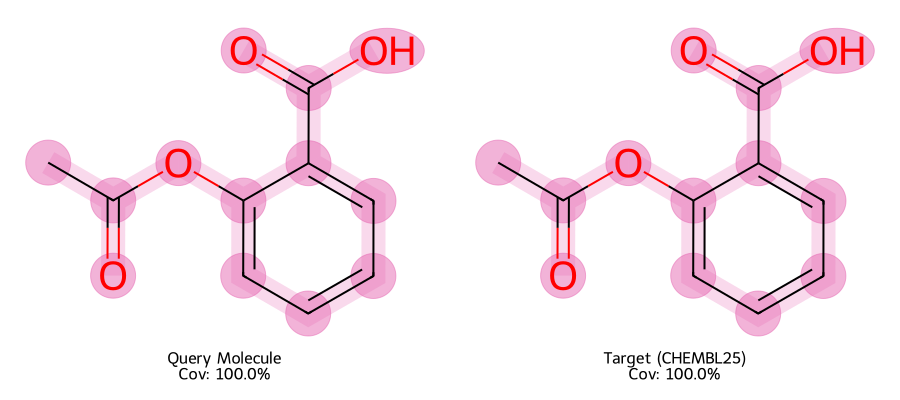

--------------------------------------------------------------------------------
🎯 Target ID:           ChEMBL_T_1337
📝 Full Protein Name:   Homeodomain-interacting protein kinase 1
🧬 Gene Name:           CHEMBL5427
🔗 UniProt ID:          Q86Z02
   • Database ID:       CHEMBL4580191
   • Query Coverage:    76.9%
   • Target Coverage:   83.3%
   • Class:             Type 4 (Multivalent Multitarget)

Query Func Groups:  carbonyl compound (2), ketone (1), alcohol (1)
Target Func Groups: carbonyl compound (2), ketone (2)


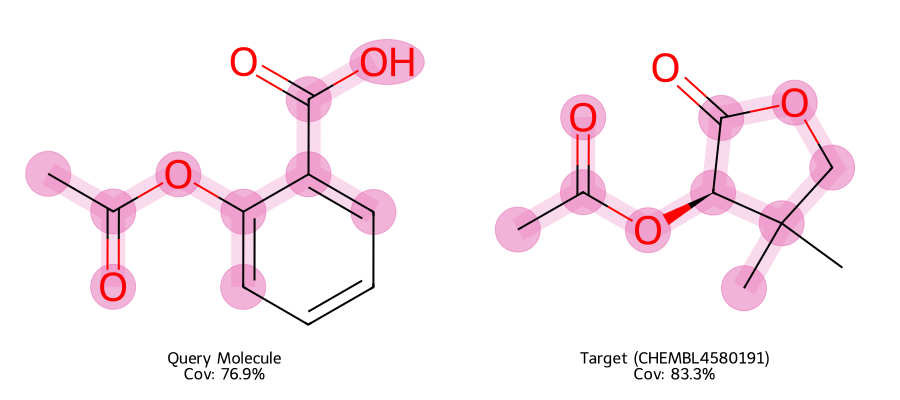

--------------------------------------------------------------------------------
🎯 Target ID:           ChEMBL_T_2269
📝 Full Protein Name:   Opioid receptors; mu & delta
🧬 Gene Name:           CHEMBL2095149
🔗 UniProt ID:          P35372
   • Database ID:       CHEMBL1439452
   • Query Coverage:    84.6%
   • Target Coverage:   78.6%
   • Class:             Type 4 (Multivalent Multitarget)

Query Func Groups:  carbonyl compound (2), ketone (1), alcohol (1)
Target Func Groups: carbonyl compound (1), ketone (1)


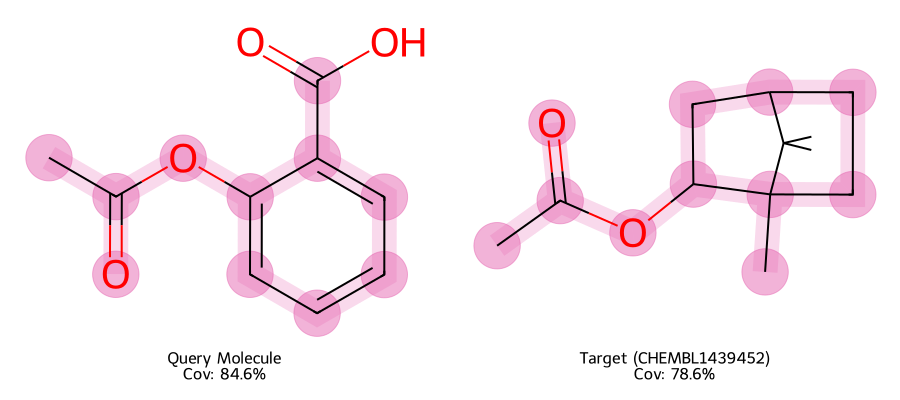



🔥 Query: IMATINIB 🔥
--------------------------------------------------------------------------------
🎯 Target ID:           ChEMBL_T_2003
📝 Full Protein Name:   Bromodomain adjacent to zinc finger domain protein 2B
🧬 Gene Name:           CHEMBL1741220
🔗 UniProt ID:          Q9UIF8
   • Database ID:       CHEMBL3040018
   • Query Coverage:    97.3%
   • Target Coverage:   100.0%
   • Class:             Type 4 (Multivalent Multitarget)

Query Func Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target Func Groups: carbonyl compound (1), amide (1), secondary amine (3), tertiary amine (1), pyridine (1), pyrimidine (1)


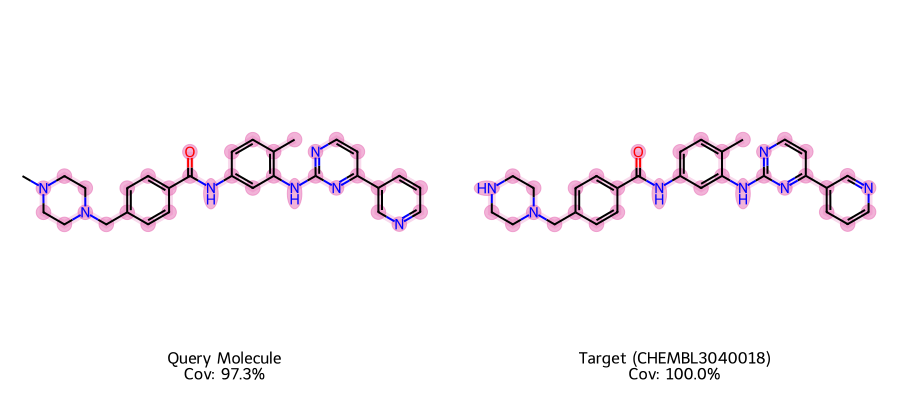

--------------------------------------------------------------------------------
🎯 Target ID:           ChEMBL_T_1349
📝 Full Protein Name:   Huntingtin
🧬 Gene Name:           CHEMBL5514
🔗 UniProt ID:          P42858
   • Database ID:       CHEMBL423288
   • Query Coverage:    64.9%
   • Target Coverage:   100.0%
   • Class:             Type 4 (Multivalent Multitarget)

Query Func Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target Func Groups: carbonyl compound (1), ketone (1), amide (1), secondary amine (2), pyridine (1), pyrimidine (1)


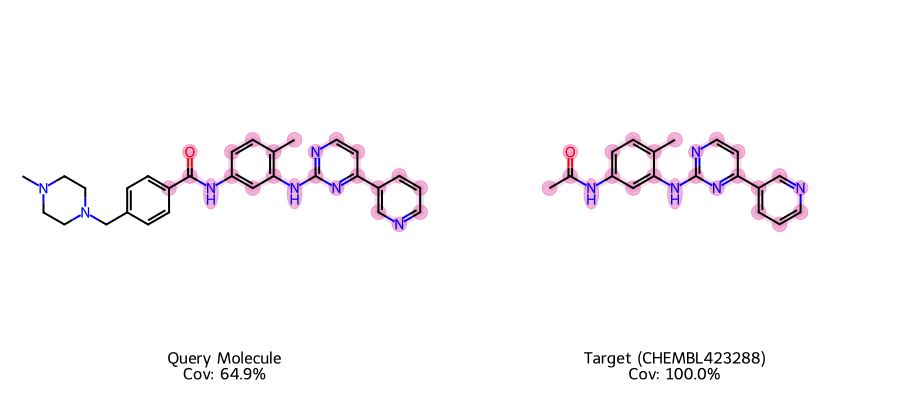

--------------------------------------------------------------------------------
🎯 Target ID:           ChEMBL_T_3118
📝 Full Protein Name:   CDK12/Cyclin K
🧬 Gene Name:           Unknown
🔗 UniProt ID:          Unknown
   • Database ID:       CHEMBL4791549
   • Query Coverage:    48.6%
   • Target Coverage:   100.0%
   • Class:             Type 4 (Multivalent Multitarget)

Query Func Groups:  carbonyl compound (1), amide (1), secondary amine (2), tertiary amine (2), pyridine (1), pyrimidine (1)
Target Func Groups: primary amine (1), pyridine (2)


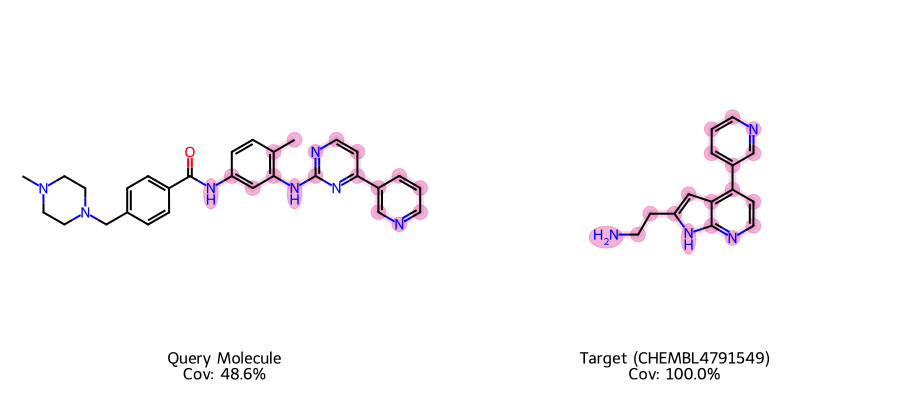

In [5]:
# Set your paths 
DB_DIRECTORY = "/storage/savi/saveenas/Projects/SynGlue_Py/data"
OUTPUT_DIRECTORY = "/storage/savi/saveenas/Projects/SynGlue_Py/outputs/Screening_Test"
QUERY_CSV = "query.csv"

# Run the unified engine with 4 workers for the test
run_unified_pipeline(
    db_dir=DB_DIRECTORY, 
    output_dir=OUTPUT_DIRECTORY, 
    csv_path=QUERY_CSV, 
    num_workers=4
)

In [15]:
DB_DIRECTORY = "/storage/savi/saveenas/Projects/SynGlue_Py/data"
OUTPUT_DIRECTORY = "/storage/savi/saveenas/Projects/SynGlue_Py/outputs/Screening_Test"
QUERY_CSV = "query.csv"

run_unified_pipeline(
    db_dir=DB_DIRECTORY,
    output_dir=OUTPUT_DIRECTORY,
    csv_path=QUERY_CSV,
    num_workers=4
)

NameError: name 'run_unified_pipeline' is not defined